In [1]:
import os 
from pathlib import Path
import shutil
import pandas as pd 

In [4]:
df = pd.read_csv("/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/NC/dugong_environmental_variables_NC.csv")

In [3]:
df['stem_filename'] = df['label_name'].apply(lambda x:Path(x).stem)


In [5]:
df.shape

(3546, 25)

In [7]:
df['stem_filename'] = df['label_name'].apply(lambda x: Path(x).stem)
    
# Ensure it don't have duplicates and set the index to the stem string
# drop duplicates one row per image
df_mapped = df.drop_duplicates(subset=['stem_filename'], keep='first')
df_mapped = df_mapped.select_dtypes(include=['str']).fillna('Pas')

In [21]:
df_mapped.isnull().sum()

label_name               0
turbidity_local          0
sun_glitter              0
cloud_reflection         0
habitat_type             0
background_dugong        0
background_complexity    0
dugong_position          0
calf_presence            0
calf                     0
group                    0
coral                    0
sand                     0
dense_seagrass           0
open_sea                 0
sparse_seagrass          0
stem_filename            0
dtype: int64

In [22]:
df_mapped

,label_name,turbidity_local,sun_glitter,cloud_reflection,habitat_type,background_dugong,background_complexity,dugong_position,calf_presence,calf,group,coral,sand,dense_seagrass,open_sea,sparse_seagrass,stem_filename
0,GH014205-611f8c7997ea4_1808.txt,no,0-25,0-25,coral,coral,medium,water_col,no,no,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1808
1,GH014205-611f8c7997ea4_1809.txt,no,0-25,0-25,coral,coral,medium,water_col,no,no,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1809
2,GH014205-611f8c7997ea4_1811.txt,no,0-25,0-25,coral,coral,medium,water_col,no,no,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1811
3,GH014205-611f8c7997ea4_1812.txt,no,0-25,0-25,coral,coral,medium,water_col,no,no,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1812
4,GH014205-611f8c7997ea4_1813.txt,no,0-25,0-25,coral,coral,medium,water_col,no,no,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3541,GH034199-60f003063f521_921.txt,no,0,>50,coral,coral,high,water_col,no,no,alone,P,A,A,P,A,GH034199-60f003063f521_921
3542,GH034199-60f003063f521_922.txt,no,0,>50,coral,coral,high,water_col,no,no,alone,P,A,A,P,A,GH034199-60f003063f521_922
3543,GH034199-60f003063f521_923.txt,no,0,>50,coral,coral,high,water_col,no,no,alone,P,A,A,P,A,GH034199-60f003063f521_923
3544,GH044199-60f13cee9be1c_446.txt,no,0,0-25,coral,sand,high,surface,no,no,alone,P,P,A,A,A,GH044199-60f13cee9be1c_446


In [ ]:
list_medatata_columns = ['altitude',
                            'resolution', 'sea_state', 'turbidity_global', 
                            'turbidity_local', 'sun_glitter', 'cloud_reflection',
                            'habitat_type', 'background_complexity', 'coral', 'sand', 'dense_seagrass',
                            'open_sea','sparse_seagrass','stem_filename'
                            ]

df[list_medatata_columns].drop_duplicates(subset=['stem_filename'],keep='first')

,altitude,resolution,sea_state,turbidity_global,turbidity_local,sun_glitter,cloud_reflection,habitat_type,background_complexity,group,coral,sand,dense_seagrass,open_sea,sparse_seagrass,stem_filename
0,NaN,NaN,1,1,no,0-25,0-25,coral,medium,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1808
1,NaN,NaN,1,1,no,0-25,0-25,coral,medium,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1809
2,NaN,NaN,1,1,no,0-25,0-25,coral,medium,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1811
3,NaN,NaN,1,1,no,0-25,0-25,coral,medium,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1812
4,NaN,NaN,1,1,no,0-25,0-25,coral,medium,alone,P,P,A,P,A,GH014205-611f8c7997ea4_1813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3541,NaN,NaN,0,1,no,0,>50,coral,high,alone,P,A,A,P,A,GH034199-60f003063f521_921
3542,NaN,NaN,0,1,no,0,>50,coral,high,alone,P,A,A,P,A,GH034199-60f003063f521_922
3543,NaN,NaN,0,1,no,0,>50,coral,high,alone,P,A,A,P,A,GH034199-60f003063f521_923
3544,NaN,NaN,1,2,no,0,0-25,coral,high,alone,P,P,A,A,A,GH044199-60f13cee9be1c_446


In [ ]:
###
## MOVE all folders to a unified file folder images labels

parent_folder = "/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/NC"

## make a dir to hold all images
savedir = 'images'
savedir_lab = 'labels'
save_dir_yolo = 'labels_yolo'
os.makedirs(os.path.join(parent_folder,savedir), exist_ok=True)
os.makedirs(os.path.join(parent_folder,savedir_lab), exist_ok=True)
os.makedirs(os.path.join(parent_folder,save_dir_yolo), exist_ok=True)

## 
for dir in os.listdir(parent_folder):
    print(f"Dir:{dir}")
    ## each folder has three folders with images, labels and labels_yolo
    dir_path = os.path.join(parent_folder, dir)

    if os.path.isdir(dir_path) and dir != "images" and dir != 'labels' and dir != 'labels_yolo':

        ## move images
        image_dir_path = os.path.join(dir_path,'images')
        for file in os.listdir(image_dir_path):
            src = os.path.join(dir_path,'images', file)
            dst = os.path.join(parent_folder, savedir, file)
            shutil.move(src, dst)

        ## move labels
        labels_dir_path = os.path.join(dir_path,'labels')
        for file in os.listdir(labels_dir_path):
            src = os.path.join(dir_path,'labels', file)
            dst = os.path.join(parent_folder, savedir_lab, file)
            shutil.move(src, dst)
        
        ## yolo labels
        yolo_dir_path = os.path.join(dir_path,'labels_yolo')
        for file in os.listdir(yolo_dir_path):
            src = os.path.join(dir_path,'labels_yolo', file)
            dst = os.path.join(parent_folder, save_dir_yolo, file)
            shutil.move(src, dst)

        

Dir:Flight_200
Dir:labels_yolo
Dir:Flight_222
Dir:Flight_207
Dir:Flight_213
Dir:Flight_232
Dir:Flight_196
Dir:Flight_231
Dir:Flight_235
Dir:Flight_214
Dir:Flight_219


Dir:Flight_199
Dir:Flight_197
Dir:Flight_226
Dir:Flight_212
Dir:images
Dir:Flight_211
Dir:Flight_218
Dir:Flight_234
Dir:Flight_233
Dir:dugong_environmental_variables_NC.csv
Dir:Flight_195
Dir:labels
Dir:Flight_209
Dir:Flight_198
Dir:Flight_215
Dir:Flight_220
Dir:Flight_205
Dir:Flight_225


In [ ]:
os.walk()

In [25]:
for root, dirs, files in os.walk("/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET"):
    print("Current folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files)

Current folder: /home/camarada/Documents/CDE/thesis/dataset_raw/DATASET
Subfolders: ['WP', 'NC']
Files: ['DOCUMENTATION DATASET.docx']
Current folder: /home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/WP
Subfolders: ['UM', 'GAM', 'MANTASANDY', 'FRIWEN']
Files: ['dugong_environmental_variables_WP.xlsx']
Current folder: /home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/WP/UM
Subfolders: ['UM_M5', 'UM_M2', 'images', 'UM_M6', 'UM_M3', 'UM_M1']
Files: []
Current folder: /home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/WP/UM/UM_M5
Subfolders: ['labels_yolo', 'images', 'labels']
Files: []
Current folder: /home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/WP/UM/UM_M5/labels_yolo
Subfolders: []
Files: ['MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_78.txt', 'MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_288.txt', 'MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_119.txt', 'MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_313.txt', 'MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_388.txt', 'MAN

In [6]:
def find_sub_data_sources(base_dir):
    """
    Finds all 'images' folders and their sibling 'labels_yolo' folders 
    within a nested structure.
    """
    sources = []
    base_path = Path(base_dir)
    
    # We look for all directories named 'images' regardless of how deep they are
    for img_dir in base_path.rglob("images"):
        # The parent is the mission folder (e.g., UM_M5)
        parent_dir = img_dir.parent
        label_dir = parent_dir / "labels_yolo"
        parent_1 = img_dir.parent.parent
        parent_2 = img_dir.parent.parent.parent

        if parent_1.name == "NC":
            region = parent_1.name
            subregion = "None"

        elif parent_2.name == "WP":
            region = parent_2.name
            subregion = parent_1.name
        else:
            region = "Unknown"
            subregion = "Unknown"
        
        if label_dir.exists():
            sources.append({
                "images": str(img_dir),
                "labels": str(label_dir),
                "mission_name": parent_dir.name, # e.g., 'UM_M5'
                "subregion": subregion, # e.g., 'GAM'
                "region": region # WP or NC
            })
    return sources

data_sources = find_sub_data_sources("/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET")

In [7]:
data_sources[0]


{'images': '/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/WP/UM/UM_M5/images',
 'labels': '/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/WP/UM/UM_M5/labels_yolo',
 'mission_name': 'UM_M5',
 'subregion': 'UM',
 'region': 'WP'}

In [14]:
## recursive glob
from pathlib import Path
[Path(data_sources[0]['images']).rglob("/*.jpeg")]

[<generator object Path.rglob at 0x761887677de0>]

In [19]:
for file in Path(data_sources[0]['images']).rglob("*.jpeg"):
    print(file.name)

MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_39.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_122.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_391.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_560.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_114.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_371.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_367.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_124.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_19.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_56.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_58.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_11.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_75.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_456.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0221-657c57e81272f_6.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_98.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_67.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_87.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_62.jpeg
MAN_P4_UM_M5_F2_GSP_DJI_

In [100]:
import pandas as pd
import os 
from pathlib import Path
import numpy as np

In [ ]:
! uv pip install openpyxl

### Auditing GRound Truth Values

Add information from csv to the dataset in fiftyone

In [110]:
df_nc = pd.read_csv("/share/home/e2406743/dataset/dataset/NC/dugong_environmental_variables_NC.csv")
df_wp = pd.read_excel("/share/home/e2406743/dataset/dataset/WP/dugong_environmental_variables_WP.xlsx")

In [111]:
list_columns_keep = [
    'x_center','y_center','sun_glitter', 'cloud_reflection', 'habitat_type', 'background_dugong',
       'background_complexity', 'dugong_position', 'calf_presence', 'calf',
       'group', 'coral', 'sand', 'dense_seagrass', 'open_sea'
                        ]

In [112]:
def preprocess_csv_for_detect(df, list_column_exhibit):
    """
    Preprocess to create a fo.Detection by matching each csv row with yolo format.
    THis is done by the x_center and y_center, which should by extremely similar. 
    Preprocess the CSV data by creating a 'stem_filename' column for index matching
    Also filter the DataFrame to include one row per image with the specified columns.

    Args:
    df: pandas DataFrame - The original DataFrame loaded from the CSV file.
    list_column_exhibit: List - The list of columns to retain from the original csv. 

    Returns:
    A dictionary mapping 'stem_filename' to the selected metadata columns.
    """
    ## try to rename it
    try:
        df = df.rename(columns={'picture_name':'label_name'})
    except KeyError:
        pass  # If 'picture_name' doesn't exist, do nothing

    if 'label_name' not in df.columns:
        raise KeyError("The DataFrame must contain either 'label_name' or 'picture_name' column for matching.")

    ## Handle the cloud_reflection AND sun_glitter
    ## there are conflicting values that need to be fixed
    def fix_col_cloud(string):
        if string.strip().lower() == '0':
            return '0-0'
        elif string.strip() == '':
            return 'No-value'
        else:
            return string
    
    if 'cloud_reflection' in df.columns:
        df['cloud_reflection'] = df['cloud_reflection'].astype('str').apply(lambda x:fix_col_cloud(x))
    
    if 'sun_glitter' in df.columns:
        df['sun_glitter'] = df['sun_glitter'].astype('str').apply(lambda x:fix_col_cloud(x))
    
    # handle missing values globally before filtering
    # We use a loop to fill based on the current data type of the column
    for col in list_column_exhibit:
        if col not in df.columns:
            print(f"Col: {col} not found in df. Please check csv and list_column_exhibit")
            continue
            
        try:
            # Check the type of the column and provide an appropriate "Zero" value
            if pd.api.types.is_numeric_dtype(df[col]):
                if pd.api.types.is_integer_dtype(df[col]):
                    df[col] = df[col].fillna(0)
                else:
                    df[col] = df[col].fillna(0.0)
            elif pd.api.types.is_bool_dtype(df[col]):
                df[col] = df[col].fillna(False)
            else:
                # Default for objects/strings
                df[col] = df[col].fillna("Unknown")
        except Exception as e:
            print(f"Warning: Could not fill NaNs in column {col}: {e}")
            df[col] = df[col].fillna("None")     

    # Create the stem column for matching
    df['stem_filename'] = df['label_name'].apply(lambda x: Path(x).stem)
    
    return df.set_index('stem_filename')[list_column_exhibit].reset_index()


In [113]:
# PROCESS WP
df_wp = preprocess_csv_for_detect(df_wp, list_columns_keep)

df_wp = df_wp.fillna(value= {'turbidity_local':'null','altitude':'null'})

# # fill null values
df_wp.loc[df['stem_filename'] == 'MAN_P4_FRIWEN_M11_F3_GSP_DJI_0009-66acd97abe6b7_186', 'x_center'] = 0.55895996

df_wp.loc[df['stem_filename'] == 'MAN_P4_FRIWEN_M11_F3_GSP_DJI_0009-66acd97abe6b7_186', 'y_center'] = 0.3421296

## PROCESS NC
## THERE IS NO MISSING DATA AT NC
# PROCESS NC
df_nc = preprocess_csv_for_detect(df_nc, list_columns_keep)
##df = df.fillna(value= {'turbidity_local':'null','altitude':'null'})

df_nc.isna().any(axis=0)

stem_filename            False
x_center                 False
y_center                 False
sun_glitter              False
cloud_reflection         False
habitat_type             False
background_dugong        False
background_complexity    False
dugong_position          False
calf_presence            False
calf                     False
group                    False
coral                    False
sand                     False
dense_seagrass           False
open_sea                 False
dtype: bool

In [ ]:
## init mongo db and fiftyone connection
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 

## Load dataset and views from mongodb 
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [114]:
# setup
dd = [{'view': nc_view, 'csv': df_nc},
    {'view': wp_view, 'csv': df_wp}]

for d in dd:
    view = d['view']
    df = d['csv']
    
    # dict will store: { filepath: fo.Detections }
    audit_map = {}
    
    # Iterate through every image in the current view
    for filepath in view.values('filepath'):
        ppp = Path(filepath)
        sample_root = ppp.stem
        
        # filter the CSV for this specific image
        df_filter = df.loc[df['stem_filename'] == sample_root]
        
        # locate the YOLO file
        # parent is 'images', grandparent is mission folder
        yolo_path = os.path.join(ppp.parent.parent, 'labels_yolo', f"{sample_root}.txt")
        
        if not os.path.exists(yolo_path):
            continue

        with open(yolo_path, 'r') as file:
            yolo_rows = [line.strip().split() for line in file if line.strip()]

        audit_detections = []

        # Match YOLO boxes with CSV rows
        for y_row in yolo_rows:
            y_xc, y_yc = float(y_row[1]), float(y_row[2])
            y_w, y_h = float(y_row[3]), float(y_row[4])
            cls_id = y_row[0]

            match_ = df_filter[
                np.isclose(df_filter['x_center'], y_xc, atol=1e-4) & 
                np.isclose(df_filter['y_center'], y_yc, atol=1e-4)
            ]
            
            # Conversion to FiftyOne coords
            tl_x = y_xc - (y_w / 2)
            tl_y = y_yc - (y_h / 2)
            
            label = "Dugong" if cls_id == "0" else str(cls_id)
            detection = fo.Detection(label=label, bounding_box=[tl_x, tl_y, y_w, y_h])

            # 4. Inject Metadata Attributes
            if not match_.empty:
                row = match_.iloc[0]
                detection["sun_glitter"] = row.get("sun_glitter","0-0")
                detection["cloud_reflection"] = row.get("cloud_reflection","Null")
                detection["habitat_type"] = row.get("habitat_type","Null")
                detection["background_dugong"] = row.get("background_dugong","Null")
                detection["background_complexity"] = row.get("background_complexity","Null")
                detection["dugong_position"] = row.get("dugong_position","Null")
                detection["calf_presence"] = row.get("calf_presence","Null")
                detection["calf"] = row.get("calf","Null")
                detection["group"] = row.get("group","Null")
                detection["coral"] = row.get("coral","Null")
                detection["sand"] = row.get("sand","Null")
                detection["dense_seagrass"] = row.get("dense_seagrass","Null")
                detection["open_sea"] = row.get("open_sea","Null")
                detection["is_verified"] = True 
            else:
                detection["is_verified"] = False 

            audit_detections.append(detection)

        # Map the collection of detections to the image filepath
        audit_map[filepath] = fo.Detections(detections=audit_detections)

    # 5. BULK UPDATE the dataset/view
    # This is much faster than sample.save()
    view.set_values("audit", audit_map, key_field="filepath")
    print(f"Finished auditing {len(audit_map)} images for this view.")

Finished auditing 716 images for this view.
Finished auditing 2039 images for this view.


In [115]:
# Check how many samples in the FULL dataset now have the 'audit' detections
total_audited = dataset.exists("audit").count()
print(f"Total samples with audit field: {total_audited} / {len(dataset)}")

# Inspect the schema of the union
print(dataset.get_field_schema())

Total samples with audit field: 2755 / 2755
OrderedDict([('id', <fiftyone.core.fields.ObjectIdField object at 0x7f092405c890>), ('filepath', <fiftyone.core.fields.StringField object at 0x7f092405c190>), ('tags', <fiftyone.core.fields.ListField object at 0x7f09249ad050>), ('metadata', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f092405c850>), ('created_at', <fiftyone.core.fields.DateTimeField object at 0x7f092405c150>), ('last_modified_at', <fiftyone.core.fields.DateTimeField object at 0x7f0925e4a110>), ('region', <fiftyone.core.fields.StringField object at 0x7f092405c810>), ('subregion', <fiftyone.core.fields.StringField object at 0x7f0926984090>), ('mission_name', <fiftyone.core.fields.StringField object at 0x7f092405c510>), ('sea_state', <fiftyone.core.fields.IntField object at 0x7f092405ca50>), ('turbidity_global', <fiftyone.core.fields.IntField object at 0x7f092405cb90>), ('turbidity_local', <fiftyone.core.fields.StringField object at 0x7f092494bfd0>), ('sun_glitter', 

In [116]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 26, 11, 53, 53, 642000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
    

In [ ]:
## filter the wp df based on the currently file to analysed
df_filter = df.loc[df['stem_filename']== ppp.stem]

## open the yolo .txt file 
file_path = os.path.join(ppp.parent.parent,'labels_yolo', f"{ppp.stem}.txt")

with open(file_path, 'r') as file:
    for line in file:
        print(line)

## loop each row of the filtered dataset 
## filter the wp df based on the currently file to analysed
df_filter = df.loc[df['stem_filename']== ppp.stem]
df_filter

0 0.140875 0.7711666666666667 0.02325 0.011

0 0.08275 0.7785 0.0205 0.019



,stem_filename,x_center,y_center,sun_glitter,cloud_reflection,habitat_type,background_dugong,background_complexity,dugong_position,calf_presence,calf,group,coral,sand,dense_seagrass,open_sea
6,FPLAN_P4_UM_M1_F2_GSPzip-64e33dff4c243_136,0.082750,0.778500,0-0,0-25,sand,sand,medium,surface,no,no,sparse,A,P,P,A
7,FPLAN_P4_UM_M1_F2_GSPzip-64e33dff4c243_136,0.140875,0.771167,0-0,0-25,sand,sand,medium,surface,no,no,sparse,A,P,P,A


### END ----------------------------

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def plot_yolo_annotation(image_path, label_path, class_names=None):
    """
    Plots YOLO format bounding boxes on a JPEG image.
    
    Args:
        image_path (str): Path to the .jpg image.
        label_path (str): Path to the .txt YOLO label file.
        class_names (list): Optional list of strings for category names.
    """
    # Load the image to get dimensions
    img = Image.open(image_path)
    img_width, img_height = img.size

    # Create figure and axes
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)

    # Read YOLO labels
    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.split()
        class_id = int(parts[0])
        
        # YOLO format is normalized (0 to 1)
        # x_center, y_center, width, height
        x_c, y_c, w, h = map(float, parts[1:])

        # Convert normalized coordinates to pixel coordinates
        # We need the top-left corner (x, y) for matplotlib patches
        rect_w = w * img_width
        rect_h = h * img_height
        rect_x = (x_c * img_width) - (rect_w / 2)
        rect_y = (y_c * img_height) - (rect_h / 2)

        # Create a Rectangle patch
        rect = patches.Rectangle(
            (rect_x, rect_y), rect_w, rect_h, 
            linewidth=2, edgecolor='r', facecolor='none'
        )

        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add label text
        label = class_names[class_id] if class_names else str(class_id)
        plt.text(rect_x, rect_y - 5, label, color='white', 
                 weight='bold', backgroundcolor='red', fontsize=8)

    plt.axis('off')
    plt.show()

In [1]:
image = "/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/NC/images/GH024196-60e7133bc685e_1517.jpeg"
nn = image.strip().split('/')[-1].split('.')[0] + '.txt'
label = "/home/camarada/Documents/CDE/thesis/dataset_raw/DATASET/NC/labels_yolo/" + nn


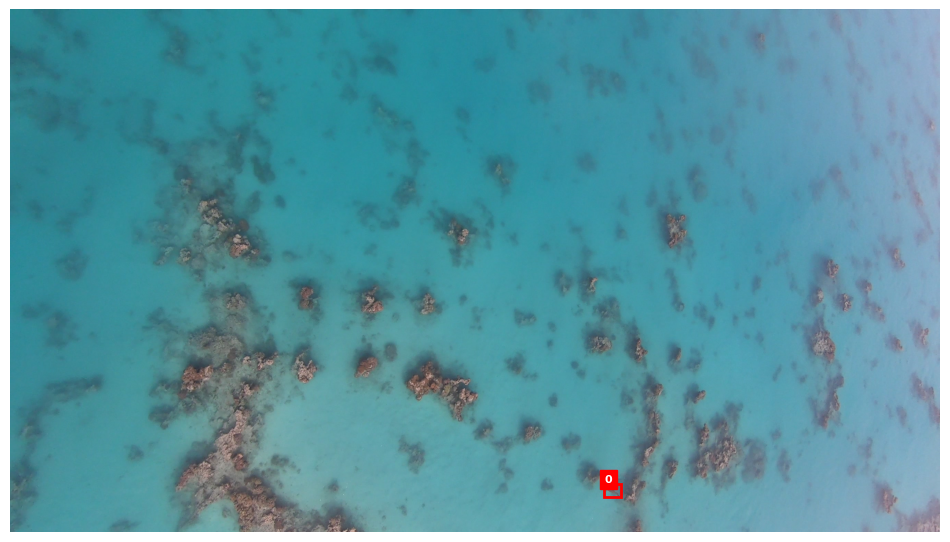

In [27]:
plot_yolo_annotation(
    image, label
)

In [2]:
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image

def plot_yolo_interactive(image_path, label_path, class_names=None):
    # Load image and get dimensions
    img = Image.open(image_path)
    w_img, h_img = img.size

    # Create the base image plot
    fig = px.imshow(img)

    # Read YOLO labels
    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.split()
        class_id = int(parts[0])
        x_c, y_c, w, h = map(float, parts[1:])

        # Convert normalized to pixel coordinates
        # Plotly's "shapes" use the image coordinate system (0 to width/height)
        rect_w = w * w_img
        rect_h = h * h_img
        x0 = (x_c * w_img) - (rect_w / 2)
        y0 = (y_c * h_img) - (rect_h / 2)
        x1 = x0 + rect_w
        y1 = y0 + rect_h

        # Add the bounding box as a shape
        fig.add_shape(
            type="rect",
            x0=x0, y0=y0, x1=x1, y1=y1,
            line=dict(color="red", width=3),
        )

        # Add a label trace (optional, for text on hover or display)
        label = class_names[class_id] if class_names else f"Class {class_id}"
        fig.add_trace(go.Scatter(
            x=[x0], y=[y0 - 10],
            text=[label],
            mode="text",
            textfont=dict(color="red", size=14),
            showlegend=False
        ))

    # Update layout to remove axes and enable better zooming
    fig.update_layout(dragmode='pan') # Set default drag to Pan
    fig.show()

In [3]:
plot_yolo_interactive(
    image,
    label
)